In [1]:
import sys
import os
import pandas as pd

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.helper_functions.analyse_functions import aggregate_results
import re
from src.helper_functions.plot_functions import (
    plot_grid,
    plot_with_bands,
    plot_heatmap,
    plot_scatter_markers,
)
import ast
import numpy as np
from functools import partial
import re

In [2]:
import matplotlib.pyplot as plt


rcparams = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 9,
    "figure.titlesize": 11,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10.5,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}

plt.rcParams.update(rcparams)

In [3]:
linestyles = {
    "RV": "-",
    "DC": "--",
    "QAP": "-.",
    "CVM": ":",
}

colors = {
    "DC": "#4285F4",  # Blue
    # "CCA": "#EA4335",  # Red
    "AC_1": "#EA4335",  # Dark Green
    "AC_sqrt": "#6AA84F",  # Light Green
    "AC_adaptive": "#673AB7",  # Purple
    "RVTest_permutation": "#FF9800",  # Light Orange
    "RVTest_asymptotic": "#FBBC05",  # Yellow
}

marker_map = {"DC": "x", "CCA": "o", "AC_1": "D", "AC_sqrt": "D", "AC_adaptive": "D", 
              "RVTest_permutation": "v", "RVTest_asymptotic": "v"}

In [4]:
def parse_matrix(value):
    """
    Convert a dataframe cell into a 2D NumPy array.

    Supports:
      - nested Python lists
      - NumPy arrays
      - string representations of nested lists
      - missing values
    """
    if value is None:
        return None

    if isinstance(value, float) and np.isnan(value):
        return None

    if isinstance(value, str):
        value = value.strip()

        if not value:
            return None

        try:
            value = ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return None

    try:
        matrix = np.asarray(value, dtype=float)
    except (TypeError, ValueError):
        return None

    if matrix.ndim != 2:
        return None

    return matrix


def classify_covariance(value, atol=1e-8, rtol=1e-5):
    """
    Classify a covariance matrix as:

      - identity
      - equicorrelated
      - diagonal
      - other
      - invalid

    An equicorrelated matrix has:
      - equal diagonal entries
      - equal off-diagonal entries

    Therefore, this also recognizes scaled equicorrelation matrices,
    not only correlation matrices with diagonal equal to 1.
    """
    matrix = parse_matrix(value)

    if matrix is None:
        return "invalid"

    n_rows, n_cols = matrix.shape

    if n_rows != n_cols:
        return "invalid"

    if not np.all(np.isfinite(matrix)):
        return "invalid"

    # Covariance matrices should be symmetric.
    if not np.allclose(matrix, matrix.T, atol=atol, rtol=rtol):
        return "other"

    identity = np.eye(n_rows)

    if np.allclose(matrix, identity, atol=atol, rtol=rtol):
        return "identity"

    diagonal = np.diag(matrix)
    off_diagonal_mask = ~np.eye(n_rows, dtype=bool)
    off_diagonal = matrix[off_diagonal_mask]

    equal_diagonal = np.allclose(
        diagonal,
        diagonal[0],
        atol=atol,
        rtol=rtol,
    )

    equal_off_diagonal = (
        n_rows <= 1
        or np.allclose(
            off_diagonal,
            off_diagonal[0],
            atol=atol,
            rtol=rtol,
        )
    )

    if equal_diagonal and equal_off_diagonal:
        return "equicorrelated"

    if np.allclose(
        matrix - np.diag(diagonal),
        0,
        atol=atol,
        rtol=rtol,
    ):
        return "diagonal"

    return "other"


def covariance_condition_number(value):
    """
    Return the matrix condition number.

    Returns:
      - a finite float for nonsingular matrices
      - np.inf for singular matrices
      - np.nan for invalid inputs
    """
    matrix = parse_matrix(value)

    if matrix is None:
        return np.nan

    n_rows, n_cols = matrix.shape

    if n_rows != n_cols:
        return np.nan

    if not np.all(np.isfinite(matrix)):
        return np.nan

    try:
        return float(np.linalg.cond(matrix))
    except np.linalg.LinAlgError:
        return np.nan


def add_covariance_summary(
    df,
    covariance_column,
    classification_column=None,
    condition_number_column=None,
):
    """
    Add covariance classification and condition-number columns.

    The input dataframe is copied, so the original is unchanged.
    """
    result = df.copy()

    if classification_column is None:
        classification_column = f"{covariance_column}_type"

    if condition_number_column is None:
        condition_number_column = f"{covariance_column}_condition_number"

    result[classification_column] = result[covariance_column].apply(
        classify_covariance
    )

    result[condition_number_column] = result[covariance_column].apply(
        covariance_condition_number
    )

    return result

In [5]:
_NOT_FOUND = object()

def parse_value(value):
        value = value.strip()

        try:
            return ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return value.strip("'\"")
        
def extract_argument(text, name):
    """
    Extract either:

        name=value
        'name': value
        "name": value

    while respecting nested lists, dictionaries, tuples, and strings.
    """
    match = re.search(
        rf"(?:['\"]?{re.escape(name)}['\"]?)\s*(?:=|:)\s*",
        text,
    )

    if not match:
        return _NOT_FOUND

    start = match.end()
    i = start

    bracket_pairs = {
        "[": "]",
        "{": "}",
        "(": ")",
    }
    closing_brackets = set(bracket_pairs.values())

    stack = []
    quote = None
    escaped = False

    while i < len(text):
        char = text[i]

        if quote is not None:
            if escaped:
                escaped = False
            elif char == "\\":
                escaped = True
            elif char == quote:
                quote = None
        else:
            if char in {"'", '"'}:
                quote = char

            elif char in bracket_pairs:
                stack.append(bracket_pairs[char])

            elif char in closing_brackets:
                if stack and char == stack[-1]:
                    stack.pop()
                elif not stack:
                    break

            elif char == "," and not stack:
                break

        i += 1

    return parse_value(text[start:i])

def parse_config_string(s):

    # Extract rough top-level key-value pairs.
    pairs = dict(re.findall(r"'([^']+)':\s*([^,}]+)", s))

    # Extract method class specifically from the method field.
    method_val_match = re.search(
        r"'method':\s*(.*?)(?=,\s*'[^']+':|$|})",
        s,
        re.DOTALL,
    )

    method_class = None
    test_function = None

    if method_val_match:
        method_val = method_val_match.group(1)

        class_match = re.search(r"<class '([^']+)'>", method_val)
        if class_match:
            method_class = class_match.group(1).split(".")[-1]

        function_match = re.search(
            r"test_function=<function ([^ ]+)",
            method_val,
        )
        if function_match:
            test_function = function_match.group(1)

        m_match = re.search(r"\bM\s*=\s*([^,\)]+)", method_val)
        if m_match:
            pairs["NN_number"] = parse_value(m_match.group(1))

        coefficient_match = re.search(
            r"\baggregate_coeff\s*=\s*([^,\)]+)",
            method_val,
        )
        if coefficient_match:
            pairs["aggregate"] = parse_value(
                coefficient_match.group(1)
            )
        approximation = extract_argument(method_val, "approximation")
        if approximation is not _NOT_FOUND:
            pairs["approximation"] = approximation

        permutation_type = extract_argument(method_val, "permutation_type")
        if permutation_type is not _NOT_FOUND:
            pairs["permutation_type"] = permutation_type
        
        adaptive_m = extract_argument(method_val, "adaptive_m")
        if adaptive_m is not _NOT_FOUND:
            pairs["adaptive_m"] = adaptive_m

    if method_class == "PermutationTest" and test_function:
        pairs["method"] = f"{method_class}_{test_function}"
    elif method_class is not None:
        pairs["method"] = method_class

    # Extract optional setup parameters only when present.
    conditional_copula = extract_argument(s, "conditional_copula")
    if conditional_copula is not _NOT_FOUND:
        pairs["conditional_copula"] = conditional_copula

    post_nonlinear_noise = extract_argument(s, "post_nonlinear_noise")
    if post_nonlinear_noise is not _NOT_FOUND:
        pairs["post_nonlinear_noise"] = post_nonlinear_noise

    n_strata = extract_argument(s, "C")
    if n_strata is not _NOT_FOUND:
        pairs["n_strata"] = n_strata

    # Support both column_covariance and column_covariance_z.
    column_covariance = extract_argument(s, "column_covariance")
    column_covariance_z = extract_argument(s, "column_covariance_z")

    if column_covariance is not _NOT_FOUND:
        pairs["column_covariance"] = column_covariance
        pairs["column_covariance_source"] = "column_covariance"
    elif column_covariance_z is not _NOT_FOUND:
        pairs["column_covariance"] = column_covariance_z
        pairs["column_covariance_source"] = "column_covariance_z"

    stratum_covariance = extract_argument(s, "stratum_covariance")
    if stratum_covariance is not _NOT_FOUND:
        pairs["stratum_covariance"] = stratum_covariance

    copula_model = extract_argument(s, "copula_model")
    if copula_model is not _NOT_FOUND:
        pairs["copula_model"] = copula_model

    latent_sim = extract_argument(s, "latent_sim")
    if latent_sim is not _NOT_FOUND:
        pairs["latent_sim"] = latent_sim

    # Extract solver from <function Name at 0x...>.
    solver_match = re.search(
        r"'solver':\s*<function ([^ ]+)",
        s,
    )
    if solver_match:
        pairs["solver"] = solver_match.group(1)

    # Clean up np.int64(...) and np.float64(...) wrappers.
    for key, value in list(pairs.items()):
        wrapper_match = re.fullmatch(
            r"np\.\w+\(([^)]+)\)",
            str(value).strip(),
        )
        if wrapper_match:
            pairs[key] = parse_value(wrapper_match.group(1))

    degree_match = re.search(r"\bdegree\s*=\s*(\d+)", s)
    if degree_match:
        pairs["degree"] = int(degree_match.group(1))

    marginals_match = re.search(
        r"'marginals':\s*\{(.*?)\}",
        s,
        re.DOTALL,
    )

    if marginals_match:
        marginals_text = marginals_match.group(1)

        marginals = dict(
            re.findall(
                r"'([^']+)'\s*:\s*'([^']+)'",
                marginals_text,
            )
        )

        pairs["marginals"] = marginals

        for variable, distribution in marginals.items():
            pairs[f"marginal_{variable}"] = distribution

    return pairs

In [6]:
def parse_result_string(s):
    # remove numpy scalar wrappers
    s_clean = re.sub(r"np\.float64\((.*?)\)", r"\1", s)

    return ast.literal_eval(s_clean)

In [7]:
results_functionals = pd.read_csv("simulation_results_20260723_1155.csv")
results_latent_sim = pd.read_csv("simulation_results_20260723_1322.csv")
# results_sbm = pd.read_csv("simulation_results_20260708_0908.csv")

results_gaussian = pd.read_csv("simulation_results_20260723_1332.csv")
results_bernoulli = pd.read_csv("simulation_results_20260723_1407.csv")

results_null = pd.read_csv("simulation_results_20260723_1554.csv")

In [8]:
results_concat = pd.concat([results_gaussian, results_bernoulli, results_functionals, results_latent_sim, results_null])

In [9]:
results = results_concat.copy()
results["args"] = results["args"].apply(parse_config_string)

In [10]:
results["ComputeAll"] = results["ComputeAll"].apply(parse_result_string)

In [11]:
# results["density"] = results["density"].apply(
#     lambda x: re.findall(r"np\.float64\((.*?)\)", x)
# )
# results["density_A"] = results["density"].apply(lambda x: x[0])
# results["density_B"] = results["density"].apply(lambda x: x[1])

In [12]:
results["edge_var"] = results["args"].apply(lambda x: x.get("edge_var", "NA"))
results["n"] = results["args"].apply(lambda x: x.get("n", "NA"))
results["k"] = results["args"].apply(lambda x: x.get("k", "NA"))
results["method"] = results["args"].apply(lambda x: x.get("method", "NA").strip("'"))
results["solver"] = results["args"].apply(lambda x: x.get("solver", "NA").strip("'"))
results['make_sparse'] = results["args"].apply(lambda x: x.get("make_sparse", "NA"))
results["use_true_x"] = results["args"].apply(
    lambda x: x.get("use_true_latent_x", "NA")
)
results["use_true_z"] = results["args"].apply(
    lambda x: x.get("use_true_latent_z", "NA")
)
results["latent_sim"] = results["args"].apply(
    lambda x: x.get("latent_sim", "NA").strip("'")
)

results["aggregate"] = results["args"].apply(
    lambda x: x.get("aggregate", "NA")
)

results["copula"] = results["args"].apply(
    lambda x: x.get("copula_model", "NA")
)
results["dgp_name"] = results["args"].apply(
    lambda x: x.get("dgp_name", "NA").strip("'")
)
results["marginal_y"] = results["args"].apply(
    lambda x: x.get("marginal_y", "NA").strip("'")
)

results["marginal_z"] = results["args"].apply(
    lambda x: x.get("marginal_z", "NA").strip("'")
)

results["rho"] = results["args"].apply(
    lambda x: x.get("rho", "NA").replace("np.float64(", "").replace(")", "")
)
results["rho"] = results["rho"].apply(lambda x: float(x) if x != "NA" else np.nan)
results["degree"] = results["args"].apply(
    lambda x: x.get("degree", "NA").replace("np.int64(", "").replace(")", "")
)
results["NN_number"] = results["args"].apply(
    lambda x: x.get("NN_number", "NA")
)
results['functional_form'] = results["args"].apply(
    lambda x: x.get("functional_form", "NA").strip("'")
)
results['sbm_covariate_sampling'] = results["args"].apply(
    lambda x: x.get("sbm_covariate_sampling", "NA").strip("'")
)
results['assortativity'] = results["args"].apply(lambda x: x.get("assortativity", "NA"))

results['x_distribution'] = results["args"].apply(
    lambda x: x.get("x_distribution", "NA").strip("'")
)

results['approximation'] = results["args"].apply(
    lambda x: x.get("approximation", "NA").strip("'")
)

results['adaptive_m'] = results['args'].apply(lambda x: x.get("adaptive_m", "NA"))

results['column_covariance'] = results['args'].apply(lambda x: x.get("column_covariance", "NA"))

In [13]:
results["n"] = results["n"].apply(
    lambda x: int(x.replace("np.int64(", "").replace(")", ""))
)
results["k"] = results["k"].apply(
    lambda x: int(x.replace("np.int64(", "").replace(")", ""))
)

In [14]:
results["dgp"] = results["args"].apply(lambda x: x.get("dgp_name", "NA"))
results["dgp_name"] = [x.split("_")[0].strip("'") for x in results["dgp"]]
# results_all["copula"] = [x.split("_")[2].strip("'") for x in results_all["dgp"]]

In [15]:
results["RelativeFrobeniusNorm_x"] = results["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_x", np.nan)
)
results["RelativeFrobeniusNorm_z"] = results["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_z", np.nan)
)

results["ProcrustesDistance_x"] = results["ComputeAll"].apply(
    lambda x: x.get("ProcrustesDistance_x", np.nan)
)
results["ProcrustesDistance_z"] = results["ComputeAll"].apply(
    lambda x: x.get("ProcrustesDistance_z", np.nan)
)

results["FalseRejection"] = results["ComputeAll"].apply(
    lambda x: x["FalseRejection"]
)
results["TrueRejection"] = results["ComputeAll"].apply(
    lambda x: x["TrueRejection"]
)
results["Rejection"] = results["ComputeAll"].apply(lambda x: x["Rejection"])

In [16]:
results["avg_rel_frob_z"] = results.groupby(
    ["n", "method", "marginals", "copula", "dgp_name"]
)["RelativeFrobeniusNorm_z"].transform("mean")

results["avg_proc_dist_z"] = results.groupby(
    ["n", "method", "marginals", "copula", "dgp_name"]
)["ProcrustesDistance_z"].transform("mean")

In [17]:
results["permutation_type"] = results["RelativeFrobeniusNorm_z"].apply(
    lambda x: "observed" if np.isnan(x) else "latent"
)

results["marginal_y"] = results["marginal_y"].replace(
    {"chi 5": "chi df=5", "t 5": "t df=5", "uniform -1 1": "unif(-1, 1)"}
)
results["marginal_z"] = results["marginal_z"].replace(
    {"chi 5": "chi df=5", "t 5": "t df=5", "uniform -1 1": "unif(-1, 1)"}
)
results.rename(columns={"TrueRejection": "Power"}, inplace=True)

results['copula'] = results['copula'].replace({'mixture_uniform':'mixture'})

In [18]:
results_all = results.copy()

In [19]:
temp = results_all[results_all["NN_number"] != "NA"].copy()
temp['NN_number'] = temp['NN_number'].astype(str)
temp["method"] = temp["method"] + "_" + temp["NN_number"]
results_all[results_all["NN_number"] != "NA"] = temp

temp = results_all[results_all["approximation"] != "NA"].copy()
temp['approximation'] = temp['approximation'].str.strip("'")
temp["method"] = temp["method"] + "_" + temp["approximation"]
results_all[results_all["approximation"] != "NA"] = temp

In [20]:
temp = results_all[results_all['adaptive_m'] != "NA"].copy()
temp['adaptive_m'] = temp['adaptive_m'].astype(str)
temp["method"] = temp["method"] + "_" + temp["adaptive_m"]
results_all[results_all['adaptive_m'] != "NA"] = temp

In [21]:
results_all["method"] = results_all["method"].replace(
    {
        "DistanceCorrelationTest": "DC",
        "RVTest": "RV",
        "ObservedCVM": "CVM",
        "CanonicalCorrelationTest": "CCA",
        "MultivariateACTest_0.5": "AC_sqrt",
        "MultivariateACTest_third": "AC_third",
        "MultivariateACTest_sqrt_avg": "AC_sqrt_avg",
        "MultivariateACTest_sqrt_max": "AC_sqrt_max",
        "MultivariateACTest_third_avg": "AC_third_avg",
        "MultivariateACTest_third_max": "AC_third_max",
        "MultivariateACTest_quarter": "AC_quarter",
        "MultivariateACTest_quarter_max": "AC_quarter_max",
        "MultivariateACTest_1": "AC_1",
        "MultivariateACTest_True": "AC_adaptive",
    }
)

In [22]:
results_all["latent_sim"] = results_all["latent_sim"].replace(
    {
        "multiplicative_noise": "mult_noise",
        "uncorrelated_bernoulli": "bernoulli",
        "joint_normal": "normal",
        "logarithmic": "log",
    }
)

In [23]:
results_all = add_covariance_summary(
    results_all,
    covariance_column="column_covariance",
)

In [24]:
results_all = results_all.fillna("NA")

### Defining different aggregations

In [25]:
# based on dgp
results_gaussian = results_all[(results_all["dgp_name"] == "GaussianNetwork")].copy()
results_bernoulli = results_all[(results_all["dgp_name"] == "BernoulliNetwork")].copy()

In [26]:
# based on rho + dgp
results_null_gaussian = results_gaussian[(results_gaussian["rho"] == 0.0)].copy()
results_alt_gaussian = results_gaussian[(results_gaussian["rho"] != 0.0)].copy()

results_null_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.0)].copy()
results_alt_bernoulli = results_bernoulli[(results_bernoulli["rho"] != 0)].copy()

In [27]:
results_null_gaussian.columns

Index(['ComputeAll', 'args', 'density', 'n', 'k', 'edge_var', 'approximation',
       'dgp', 'solver', 'rho', 'method', 'marginals', 'make_sparse',
       'use_true_x', 'use_true_z', 'latent_sim', 'aggregate', 'copula',
       'dgp_name', 'marginal_y', 'marginal_z', 'degree', 'NN_number',
       'functional_form', 'sbm_covariate_sampling', 'assortativity',
       'x_distribution', 'adaptive_m', 'column_covariance',
       'RelativeFrobeniusNorm_x', 'RelativeFrobeniusNorm_z',
       'ProcrustesDistance_x', 'ProcrustesDistance_z', 'FalseRejection',
       'Power', 'Rejection', 'avg_rel_frob_z', 'avg_proc_dist_z',
       'permutation_type', 'column_covariance_type',
       'column_covariance_condition_number'],
      dtype='object')

## Type I error

**Ensure type I error is controlled at 5%**

In [28]:
agg_null_gaussian = aggregate_results(
    results_null_gaussian,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["method", "copula", "marginal_z", "marginal_y", "column_covariance_condition_number"],
)

agg_null_bernoulli = aggregate_results(
    results_null_bernoulli,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["method", "copula", "marginal_z", "marginal_y", "column_covariance_condition_number"],
)

# agg_null_gaussian_frob = aggregate_results(
#     results_null_gaussian,
#     y_axis="FalseRejection",
#     x_axis="avg_rel_frob_x",
#     factors=["marginals", "method", "permutation_type"],
# )
# agg_null_bernoulli_frob = aggregate_results(
#     results_null_bernoulli,
#     y_axis="FalseRejection",
#     x_axis="avg_rel_frob_x",
#     factors=["marginals", "method", "permutation_type"],
# )

# agg_null_gaussian_proc = aggregate_results(
#     results_null_gaussian,
#     y_axis="FalseRejection",
#     x_axis="avg_proc_dist_x",
#     factors=["marginals", "method", "permutation_type"],
# )
# agg_null_bernoulli_proc = aggregate_results(
#     results_null_bernoulli,
#     y_axis="FalseRejection",
#     x_axis="avg_proc_dist_x",
#     factors=["marginals", "method", "permutation_type"],
# )

In [29]:
rcparams = {
    "text.usetex": False,  # Disabled LaTeX rendering
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "font.weight": "normal",  # Bolds all general text
    "font.size": 17,
    "figure.titlesize": 17,
    "figure.titleweight": "normal",  # Bolds the main figure title
    "legend.fontsize": 17,
    "legend.title_fontsize": 17,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.labelweight": "normal",  # Bolds axis labels (x, y)
    "axes.titleweight": "normal",  # Bolds axis titles
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
}

plt.rcParams.update(rcparams)

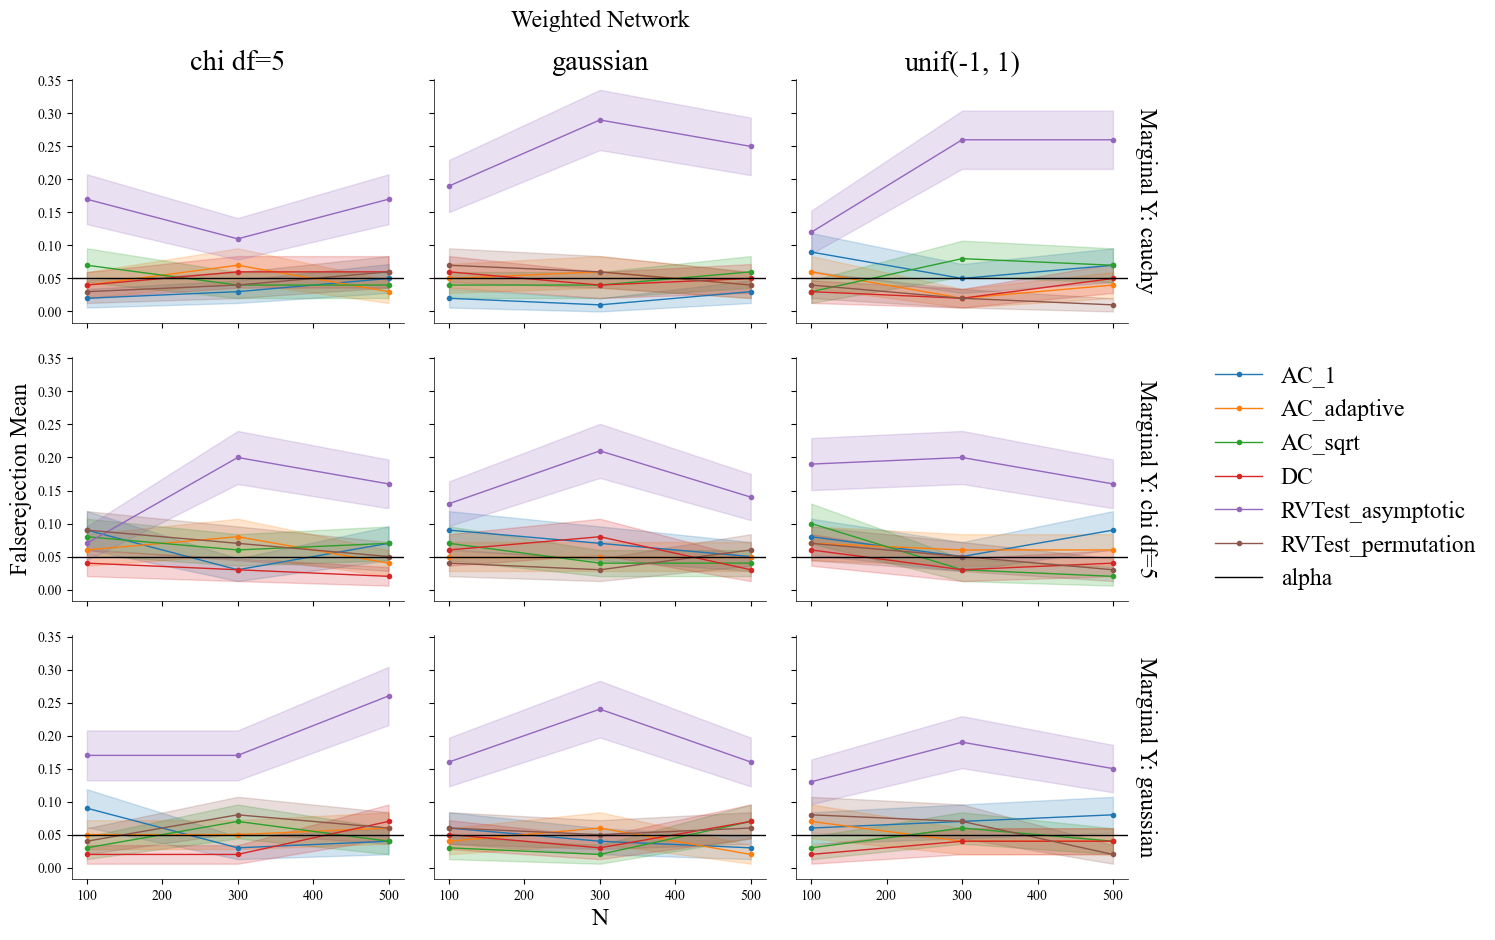

In [30]:
temp = agg_null_gaussian.copy()
temp = temp[temp["column_covariance_condition_number"] == 1].copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["method", "marginal_z", "marginal_y"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=True,
    title="Weighted Network",
    hline=0.05,
    hline_name="alpha",
    show_row_titles=True,
    show_row_names=True,
    show_col_names=False,
    #col_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
)

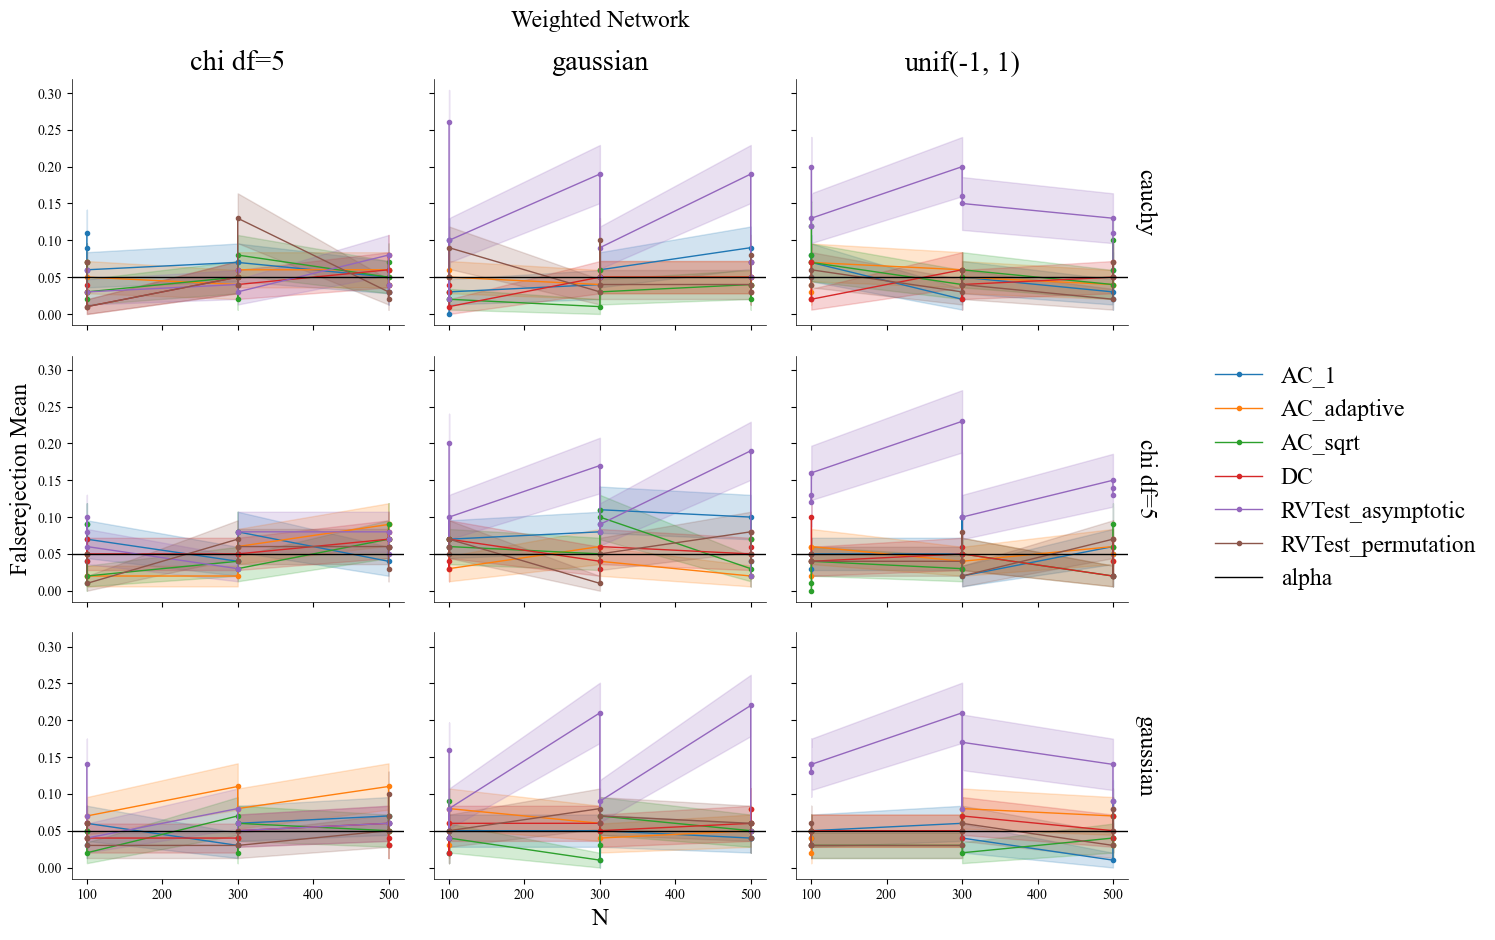

In [31]:
temp = agg_null_bernoulli.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["method", "marginal_z", "marginal_y"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=True,
    title="Weighted Network",
    hline=0.05,
    hline_name="alpha",
    show_row_titles=True,
    show_row_names=False,
    show_col_names=False,
    #col_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
)

### Power

In [32]:
agg_alt_gaussian = aggregate_results(
    results_alt_gaussian,
    y_axis="Rejection",
    x_axis="n",
    factors=["marginal_y", "marginal_z", "method", "latent_sim", "make_sparse", "functional_form", "copula", "sbm_covariate_sampling", "assortativity", "x_distribution"],
)

agg_alt_bernoulli = aggregate_results(
    results_alt_bernoulli,
    y_axis="Rejection",
    x_axis="n",
    factors=["marginal_y", "marginal_z", "method", "latent_sim", "make_sparse", "functional_form", "copula", "sbm_covariate_sampling", "assortativity", "x_distribution"],
)

In [33]:
copulas = ['gaussian', 'student_t', 'clayton', 'mixture']
marginals_z = ['gaussian', 'chi df=5']
marginals_y = ['gaussian', 'chi df=5', 'cauchy']

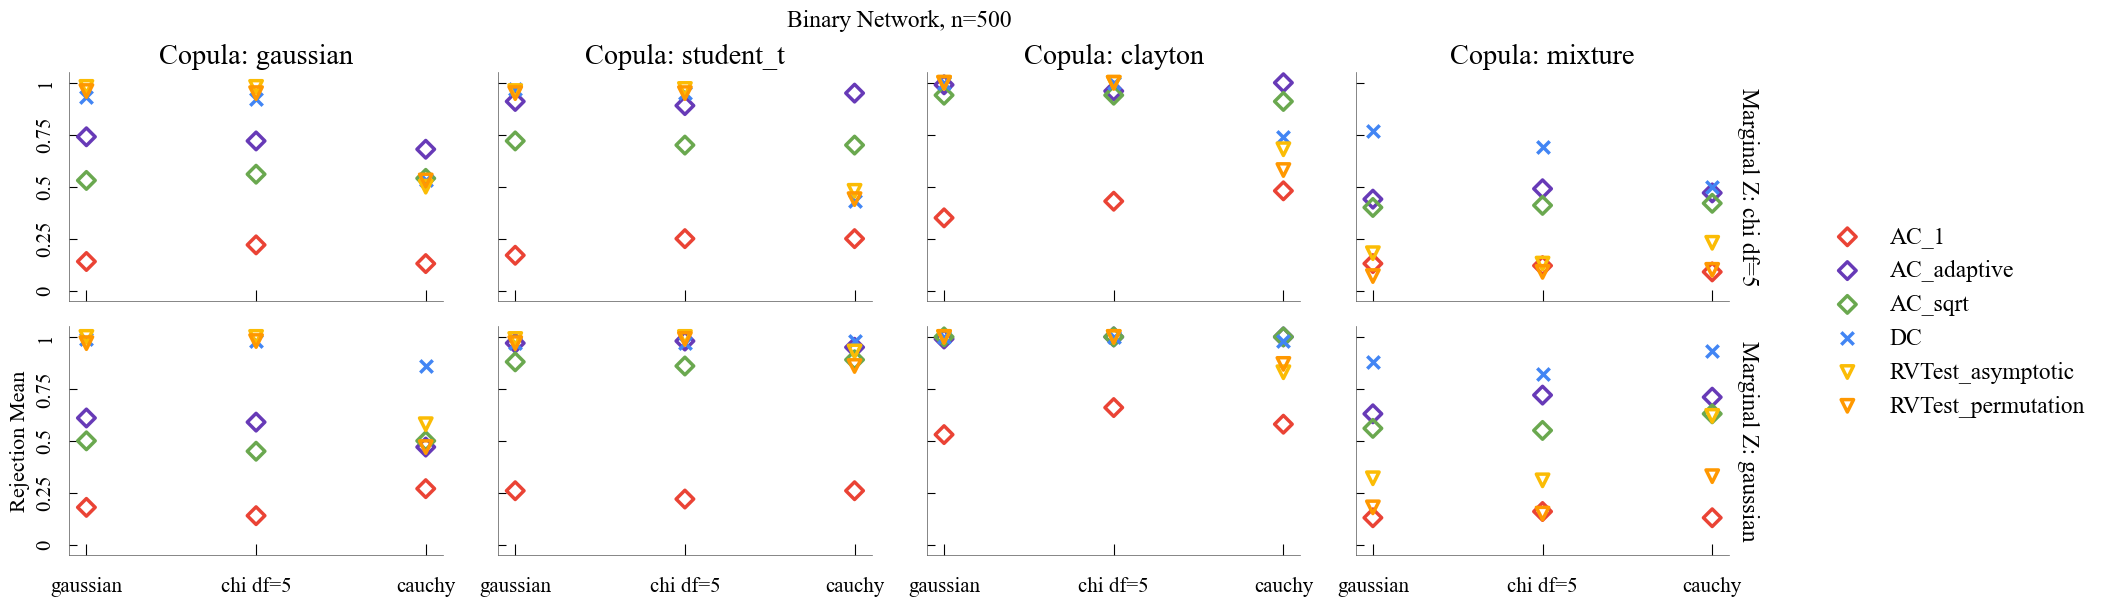

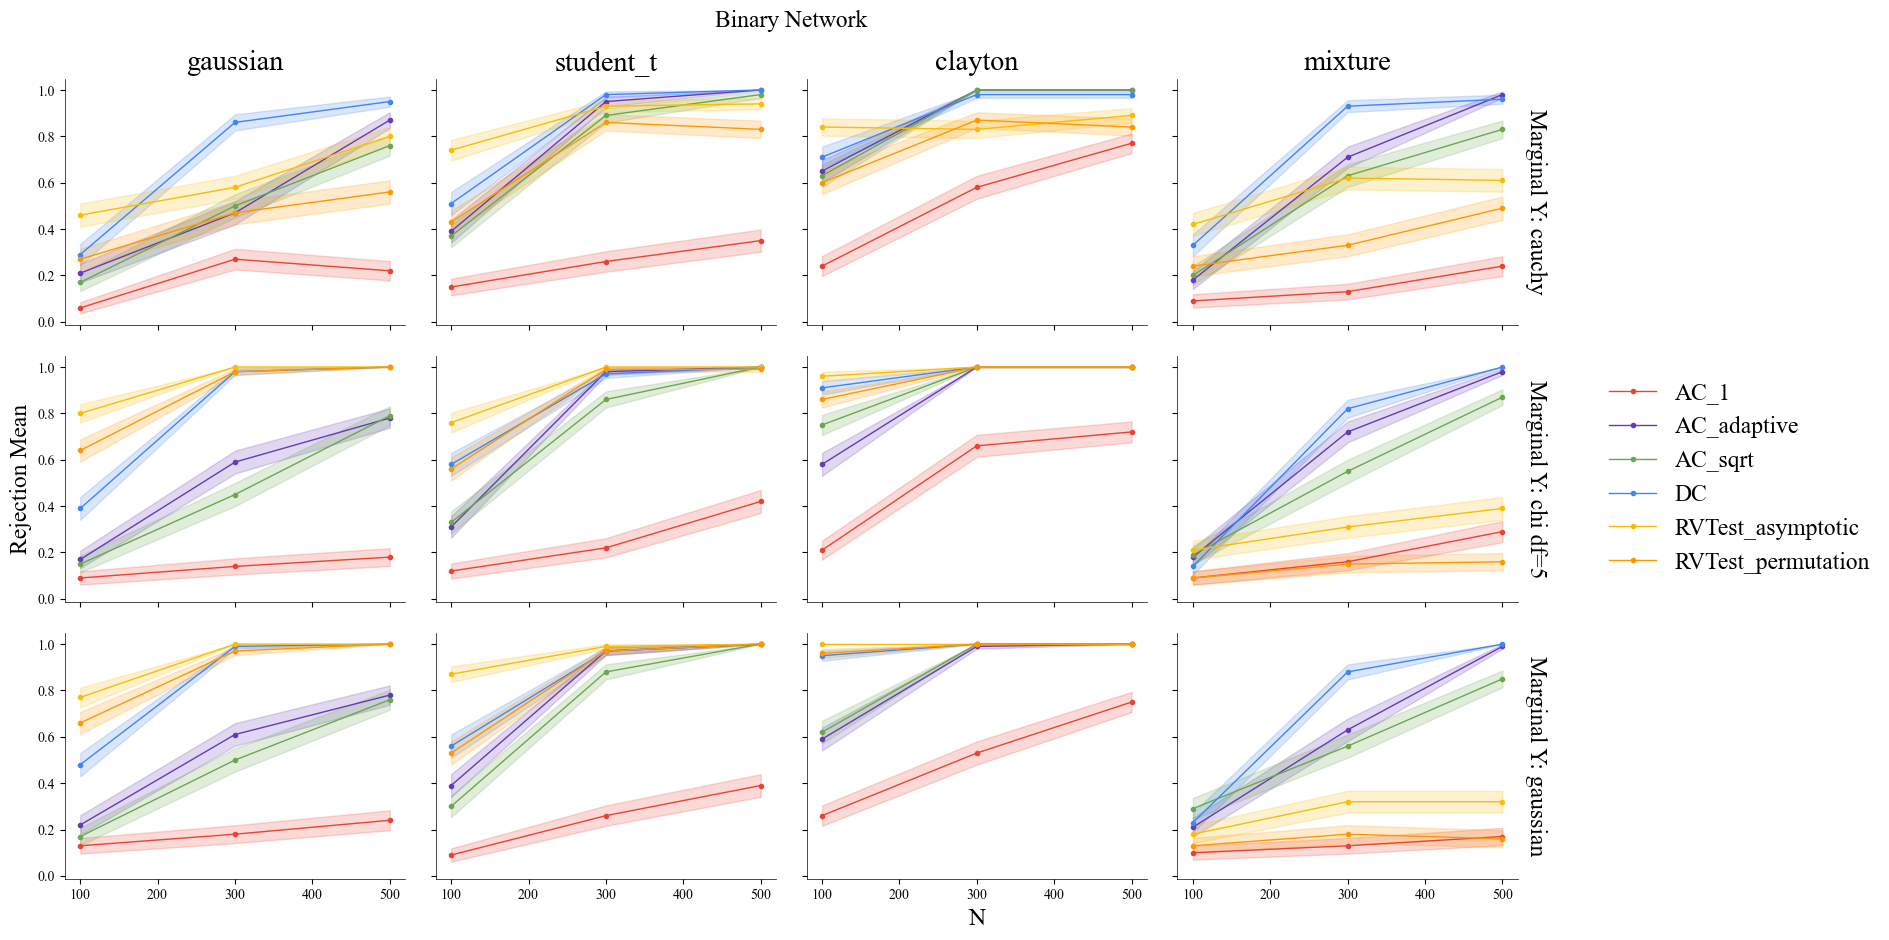

In [34]:
temp = agg_alt_bernoulli.copy()
temp = temp[temp['copula'].isin(copulas)]
temp = temp[temp['marginal_z'].isin(marginals_z)]
temp = temp[temp['marginal_y'].isin(marginals_y)]
temp = temp[temp['method'].isin(colors.keys())]

plot_grid(
    grouped_stats=temp[temp['n']==300],
    plotting_function=plot_scatter_markers,
    x_axis="marginal_y",
    y_axis="Rejection_mean",
    factors=["method", "copula", 'marginal_z'],
    height=3,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    add_legend=True,
    title="Binary Network, n=500",
    show_x_axis_title=False,
    x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=15,  # ← same for y (optional)
    x_tick_rotation=0,
    x_order=marginals_y,
    col_order=copulas,
)

plot_grid(
    grouped_stats=temp[temp['marginal_z']=='gaussian'],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "copula", "marginal_y"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Binary Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
    col_order=copulas,
)

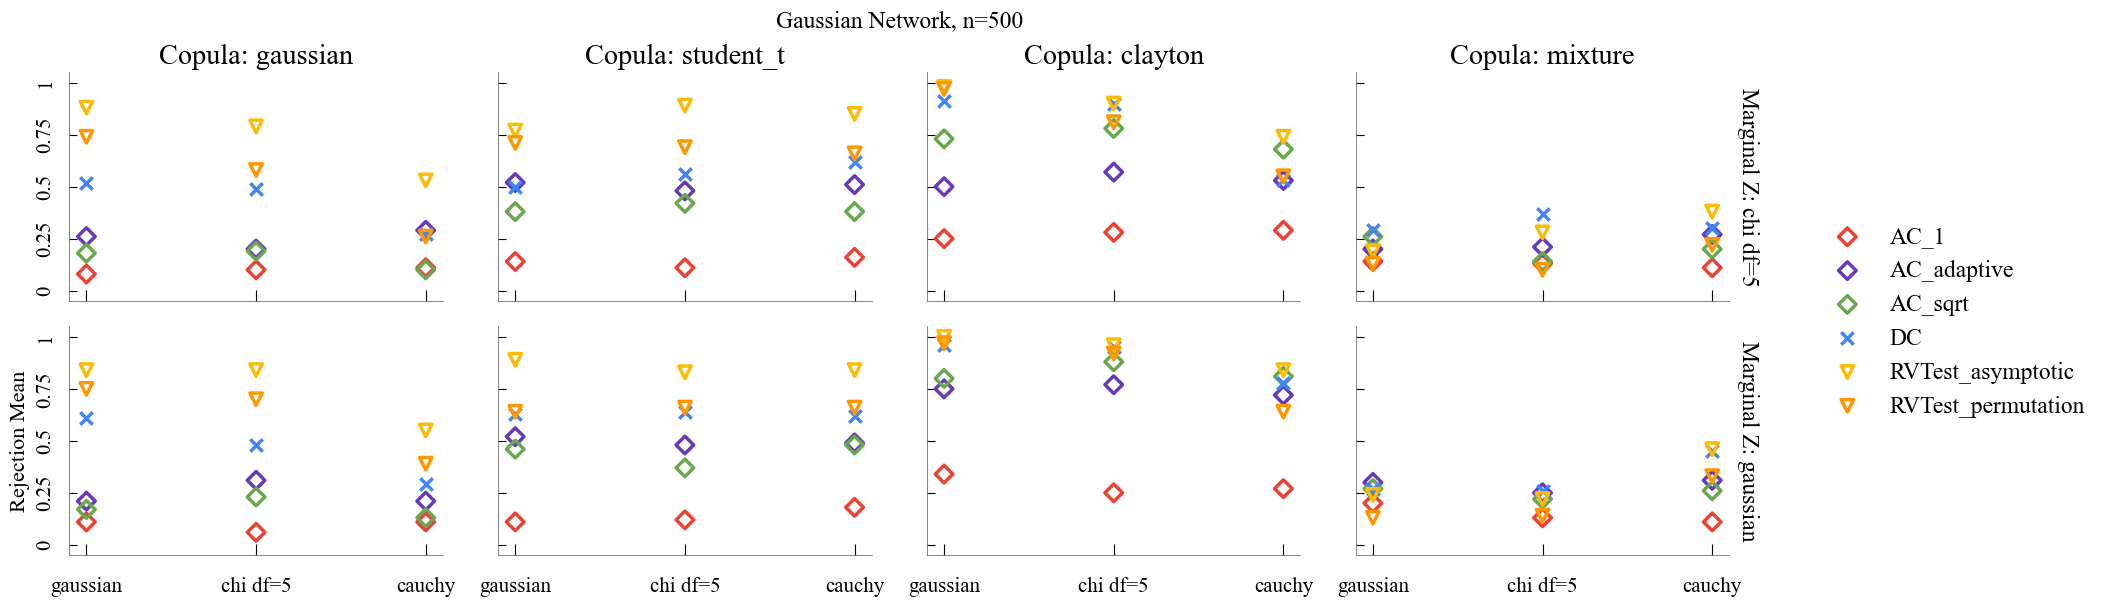

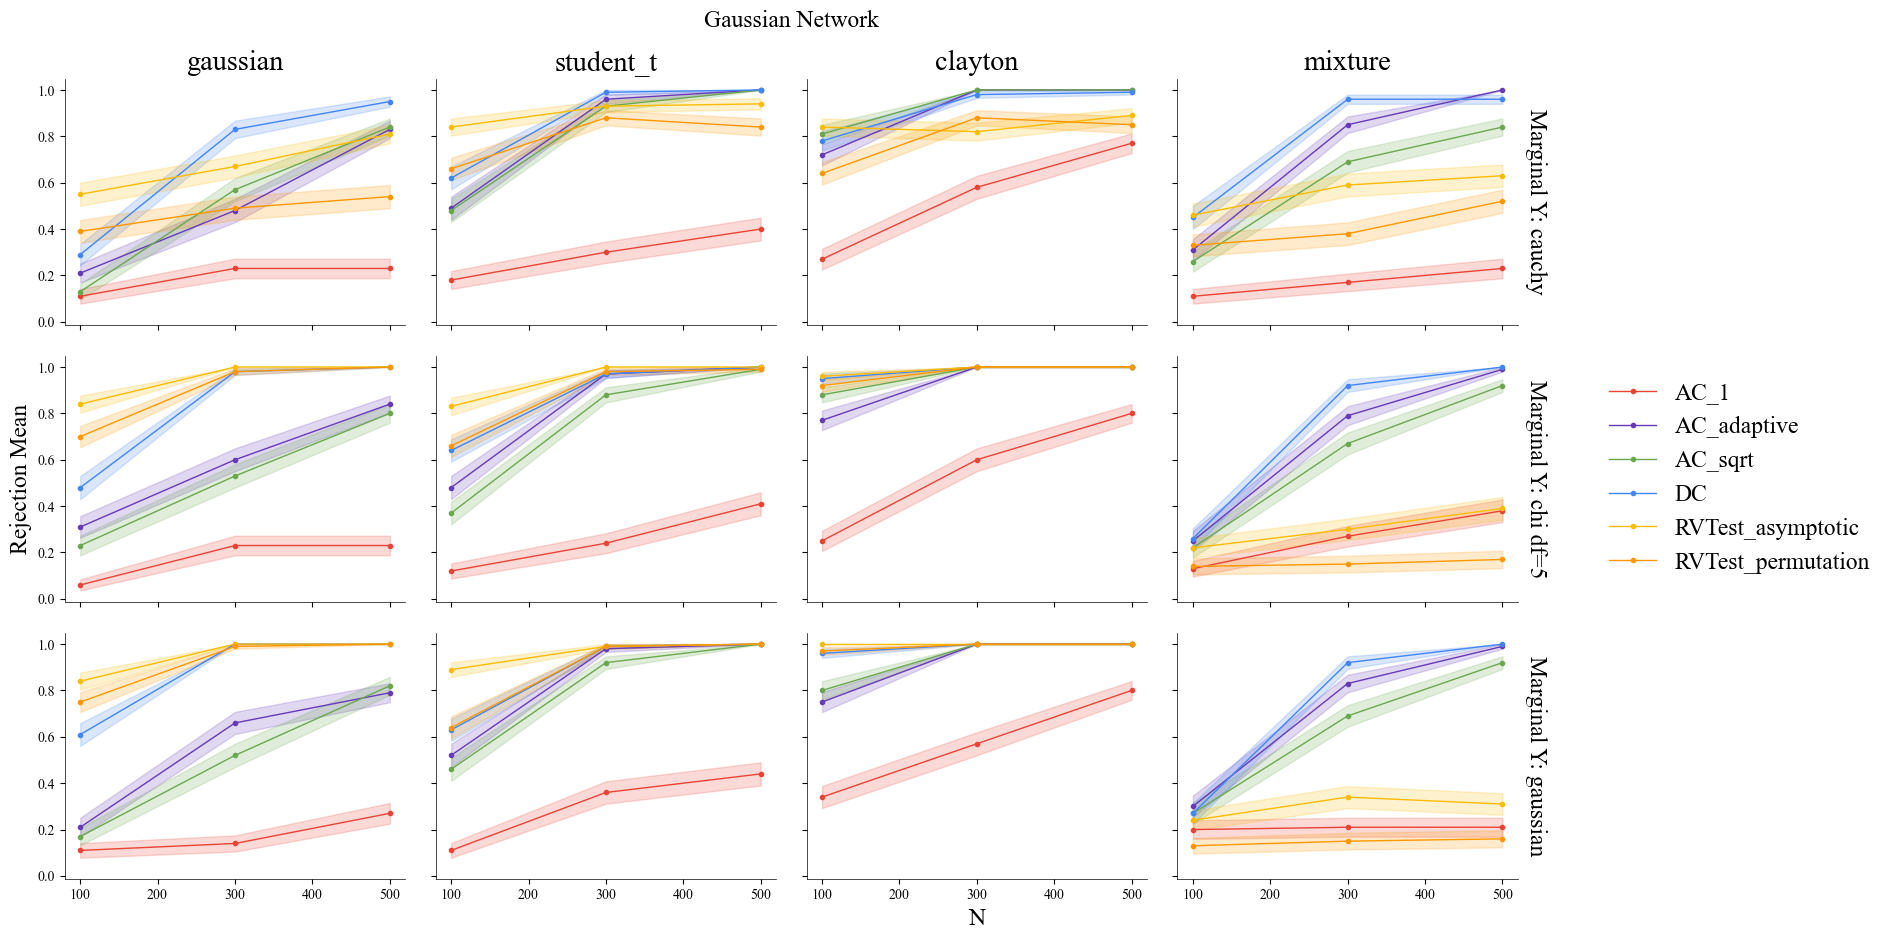

In [35]:
temp = agg_alt_gaussian.copy()
temp = temp[temp['copula'].isin(copulas)]
temp = temp[temp['marginal_z'].isin(marginals_z)]
temp = temp[temp['marginal_y'].isin(marginals_y)]
temp = temp[temp['method'].isin(colors.keys())]

plot_grid(
    grouped_stats=temp[temp['n']==100],
    plotting_function=plot_scatter_markers,
    x_axis="marginal_y",
    y_axis="Rejection_mean",
    factors=["method", "copula", 'marginal_z'],
    height=3,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    add_legend=True,
    title="Gaussian Network, n=500",
    show_x_axis_title=False,
    x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=15,  # ← same for y (optional)
    x_tick_rotation=0,
    x_order=marginals_y,
    col_order=copulas,
)

plot_grid(
    grouped_stats=temp[temp['marginal_z']=='gaussian'],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "copula", "marginal_y"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Gaussian Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
    col_order=copulas,
)

In [36]:
all_sim = [
    "linear",
    "exponential",
    "cubic",
    "step",
    "circle",
    "ellipse",
    "spiral",
    "quadratic",
    "fourth_root",
    "log",
    "w_shaped",
    "two_parabolas",
    "bernoulli",
    "square",
    "diamond",
    "sin_sixteen_pi",
]

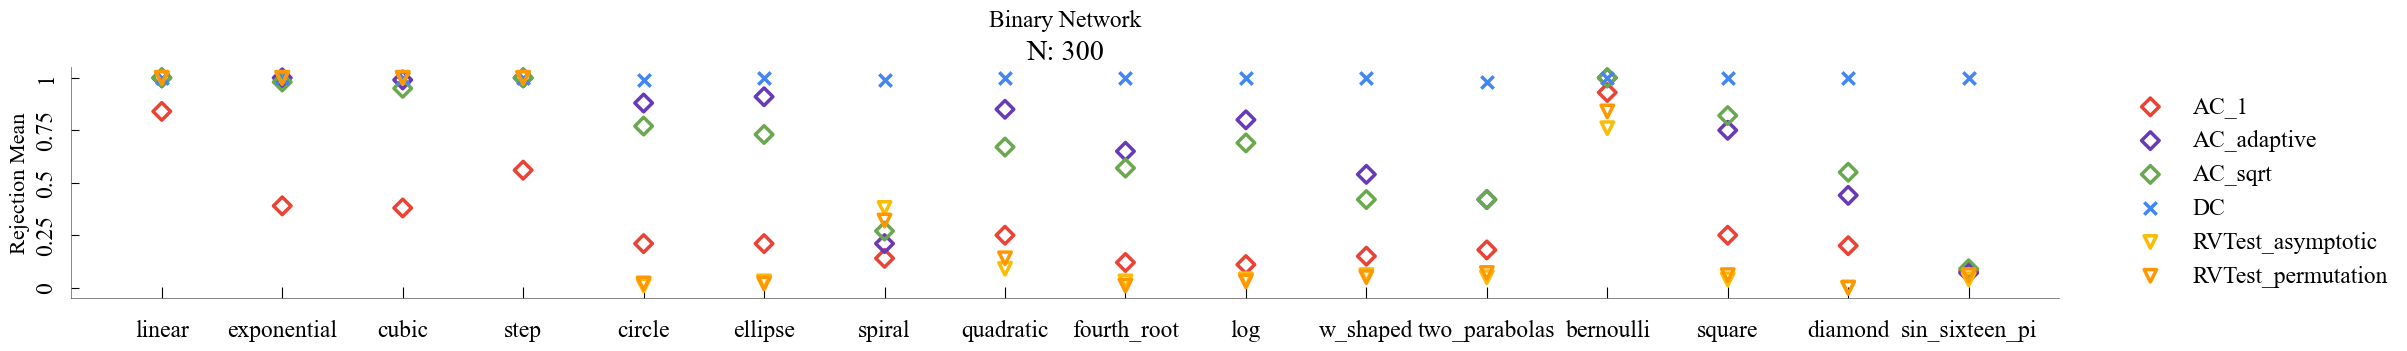

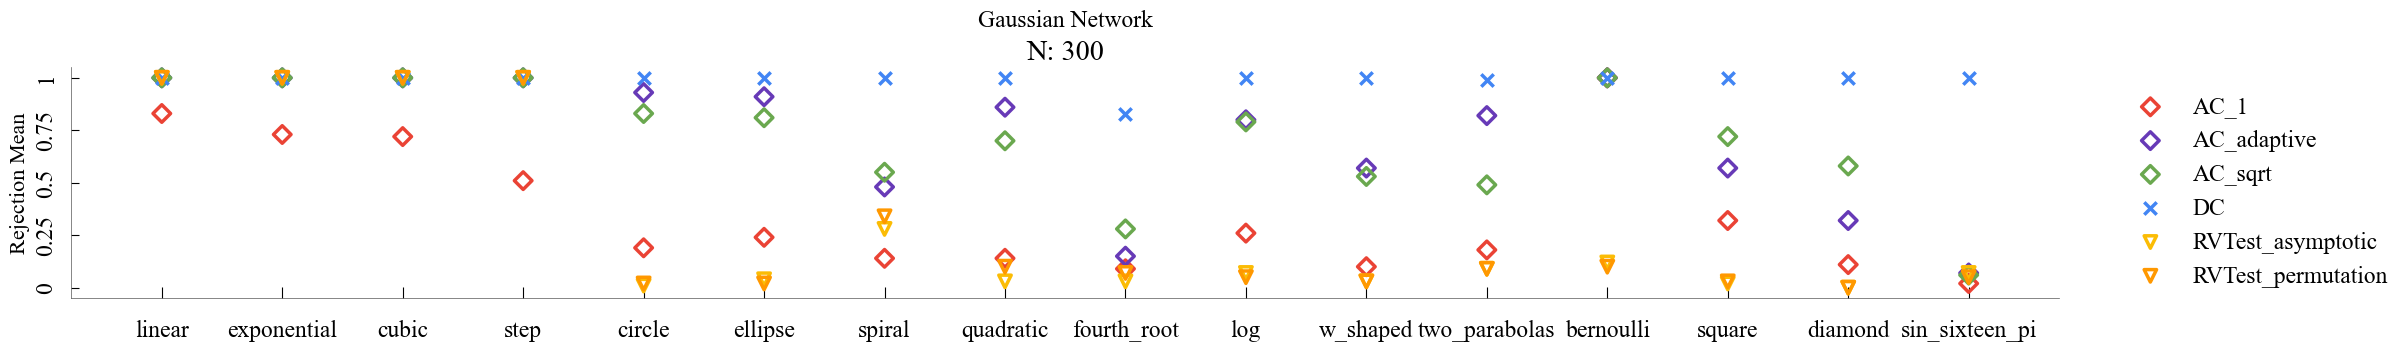

In [37]:
temp = agg_alt_bernoulli.copy()
temp = temp[temp['latent_sim'].isin(all_sim)]
temp = temp[temp['method'].isin(colors.keys())]

plot_grid(
    grouped_stats=temp[temp["n"] == 300],
    x_axis="latent_sim",
    y_axis="Rejection_mean",
    factors=["method", "n"],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3.5,
    aspect=6,
    add_legend=True,
    x_order=all_sim,
    show_x_axis_title=False,
    x_tick_labelsize=17,
    y_tick_labelsize=17,
    x_tick_rotation=0,
    title="Binary Network",
)

temp = agg_alt_gaussian.copy()
temp = temp[temp['latent_sim'].isin(all_sim)]
temp = temp[temp['method'].isin(colors.keys())]

plot_grid(
    grouped_stats=temp[temp["n"] == 300],
    x_axis="latent_sim",
    y_axis="Rejection_mean",
    factors=["method", "n"],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3.5,
    aspect=6,
    add_legend=True,
    x_order=all_sim,
    show_x_axis_title=False,
    x_tick_labelsize=17,
    y_tick_labelsize=17,
    x_tick_rotation=0,
    title="Gaussian Network",
)

In [38]:
all_functional_forms = [
    "linear",
    "interaction",
    "pareto",
    "max",
    "abs_max",
    "radial",
    "sine",
    "tanh_product",
]

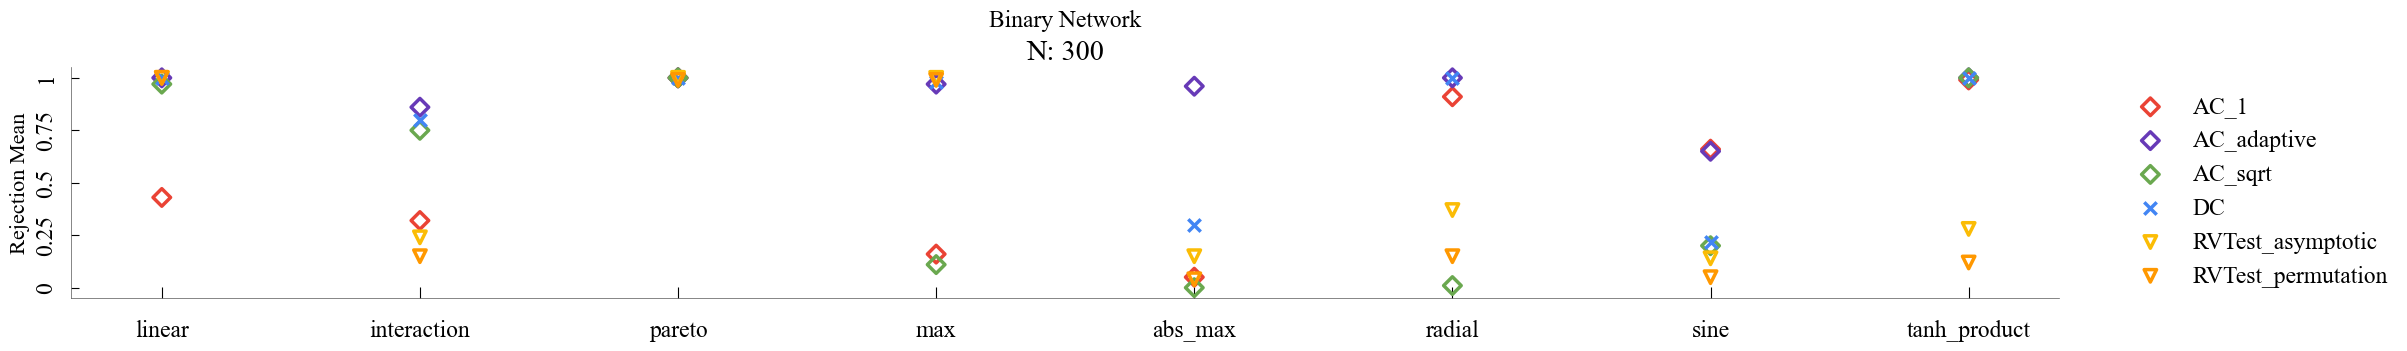

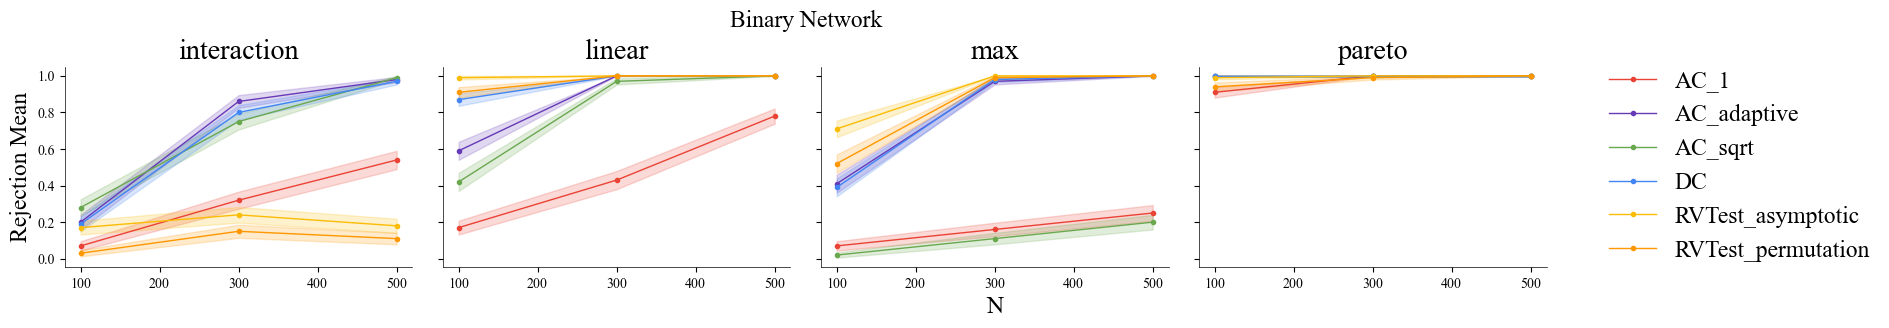

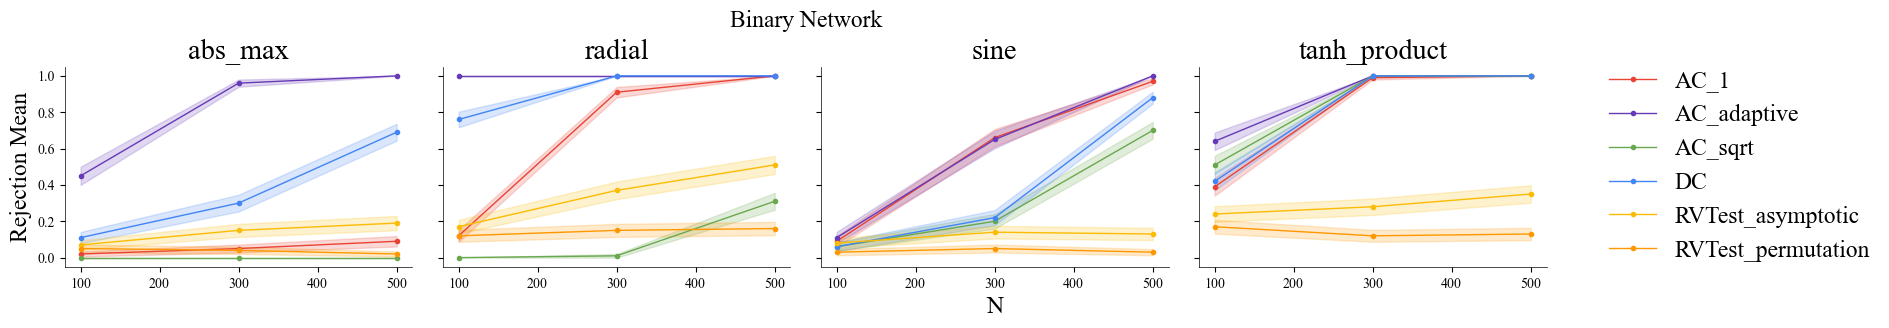

In [39]:
temp = agg_alt_bernoulli.copy()
temp = temp[temp['functional_form'].isin(all_functional_forms)]
temp = temp[temp['method'].isin(colors.keys())]

plot_grid(
    grouped_stats=temp[temp["n"] == 300],
    x_axis="functional_form",
    y_axis="Rejection_mean",
    factors=["method", "n",],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3.5,
    aspect=6,
    add_legend=True,
    x_order=all_functional_forms,
    show_x_axis_title=False,
    x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=17,  # ← same for y (optional)
    x_tick_rotation=0,
    title="Binary Network",
)


plot_grid(
    grouped_stats=temp[temp["functional_form"].isin(all_functional_forms[:4])],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "functional_form"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Binary Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
)

plot_grid(
    grouped_stats=temp[temp["functional_form"].isin(all_functional_forms[4:])],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "functional_form"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Binary Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
)

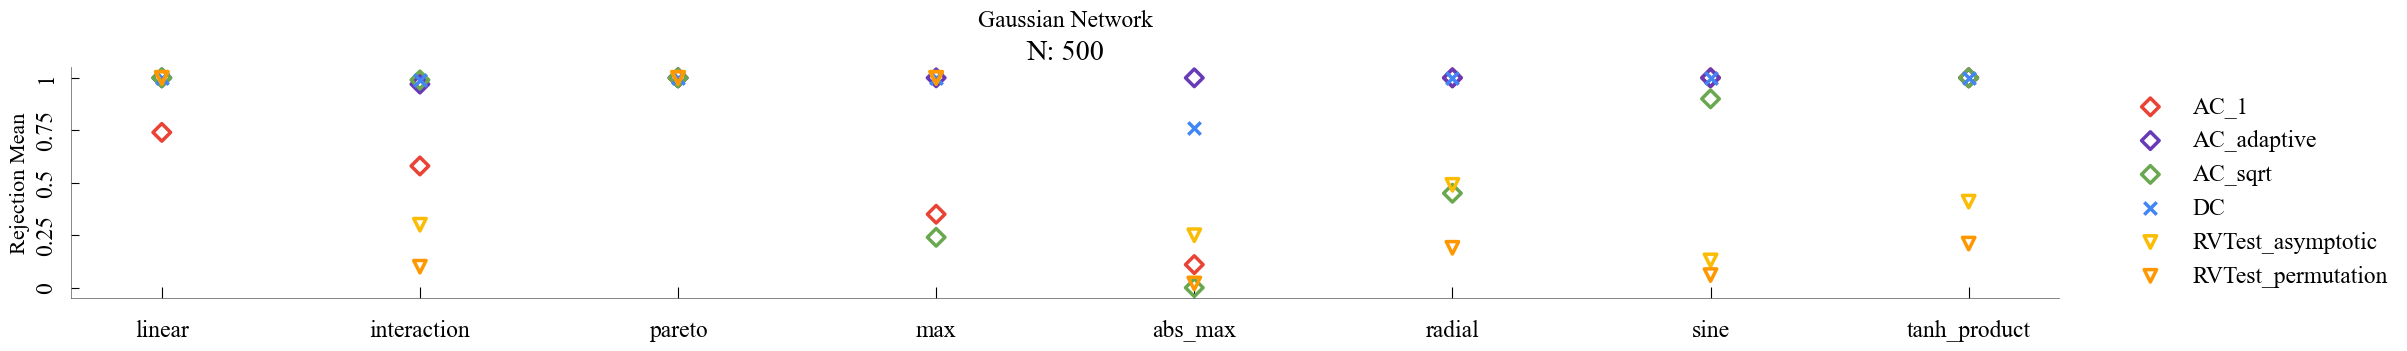

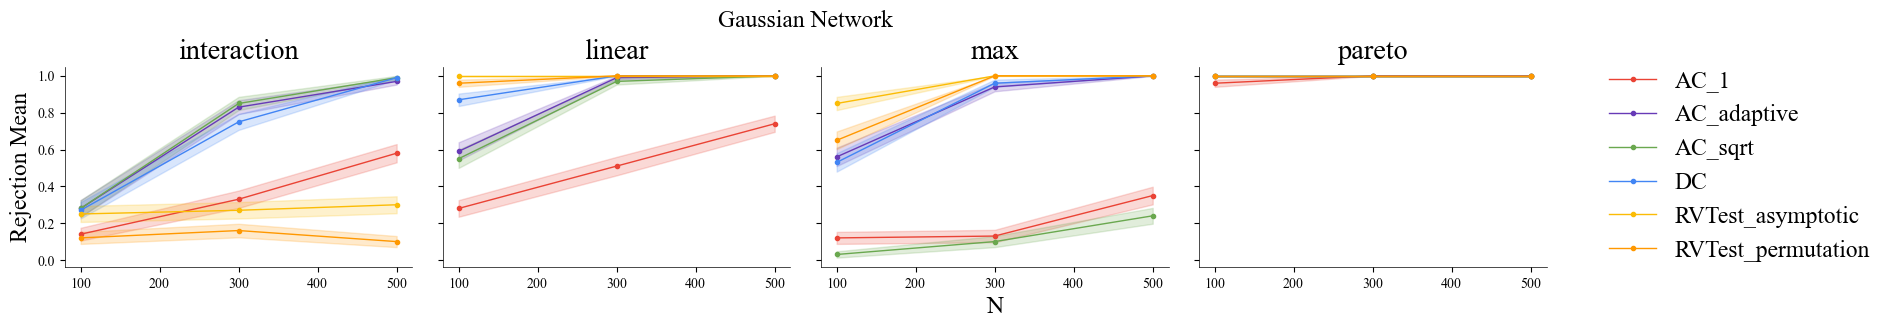

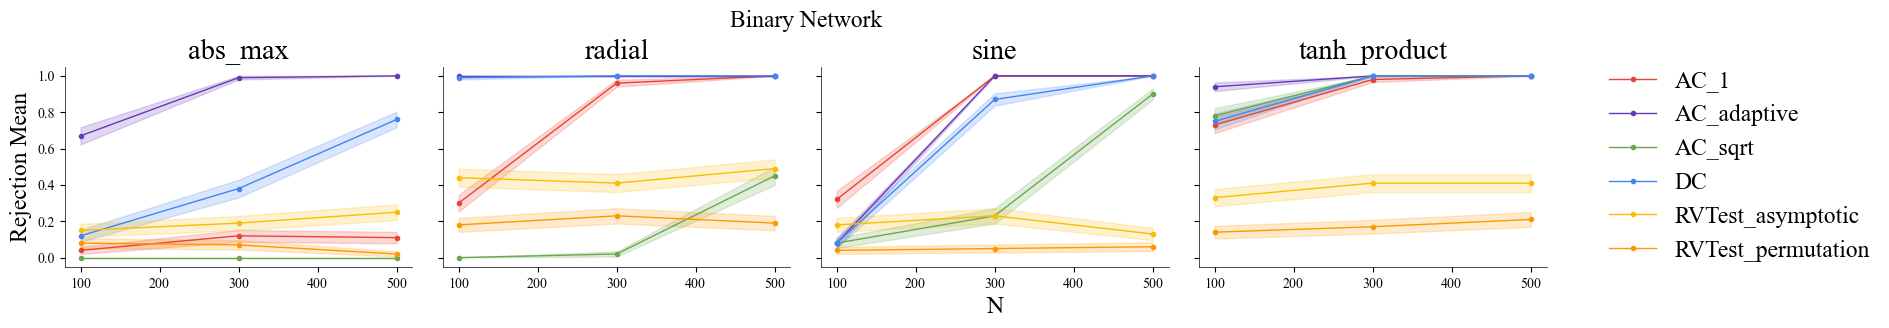

In [40]:
temp = agg_alt_gaussian.copy()
temp = temp[temp['functional_form'].isin(all_functional_forms)]
temp = temp[temp['method'].isin(colors.keys())]

plot_grid(
    grouped_stats=temp[temp["n"] == 500],
    x_axis="functional_form",
    y_axis="Rejection_mean",
    factors=["method", "n",],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3.5,
    aspect=6,
    add_legend=True,
    x_order=all_functional_forms,
    show_x_axis_title=False,
    x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=17,  # ← same for y (optional)
    x_tick_rotation=0,
    title="Gaussian Network",
)


plot_grid(
    grouped_stats=temp[temp["functional_form"].isin(all_functional_forms[:4])],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "functional_form"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Gaussian Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
)

plot_grid(
    grouped_stats=temp[temp["functional_form"].isin(all_functional_forms[4:])],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "functional_form"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Binary Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
)

In [41]:
all_sbm = ['step', 'softmax']

temp = agg_alt_bernoulli.copy()
temp = temp[temp['sbm_covariate_sampling'].isin(all_sbm)]
temp = temp[temp['method'].isin(colors.keys())]

plot_grid(
    grouped_stats=temp[temp["n"] == 500],
    x_axis="sbm_covariate_sampling",
    y_axis="Rejection_mean",
    factors=["method", "x_distribution", 'assortativity'],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=2.5,
    aspect=1.5,
    add_legend=True,
    x_order=all_sbm,
    show_x_axis_title=False,
    show_col_names=False,
    x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=17,  # ← same for y (optional)
    x_tick_rotation=0,
    title="Binary Network",
)

plot_grid(
    grouped_stats=temp[temp['sbm_covariate_sampling'].isin(all_sbm[1:])],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "assortativity", "x_distribution"],
    height=2.5,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Gaussian Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
)

ValueError: Number of rows must be a positive integer, not 0

<Figure size 0x0 with 0 Axes>

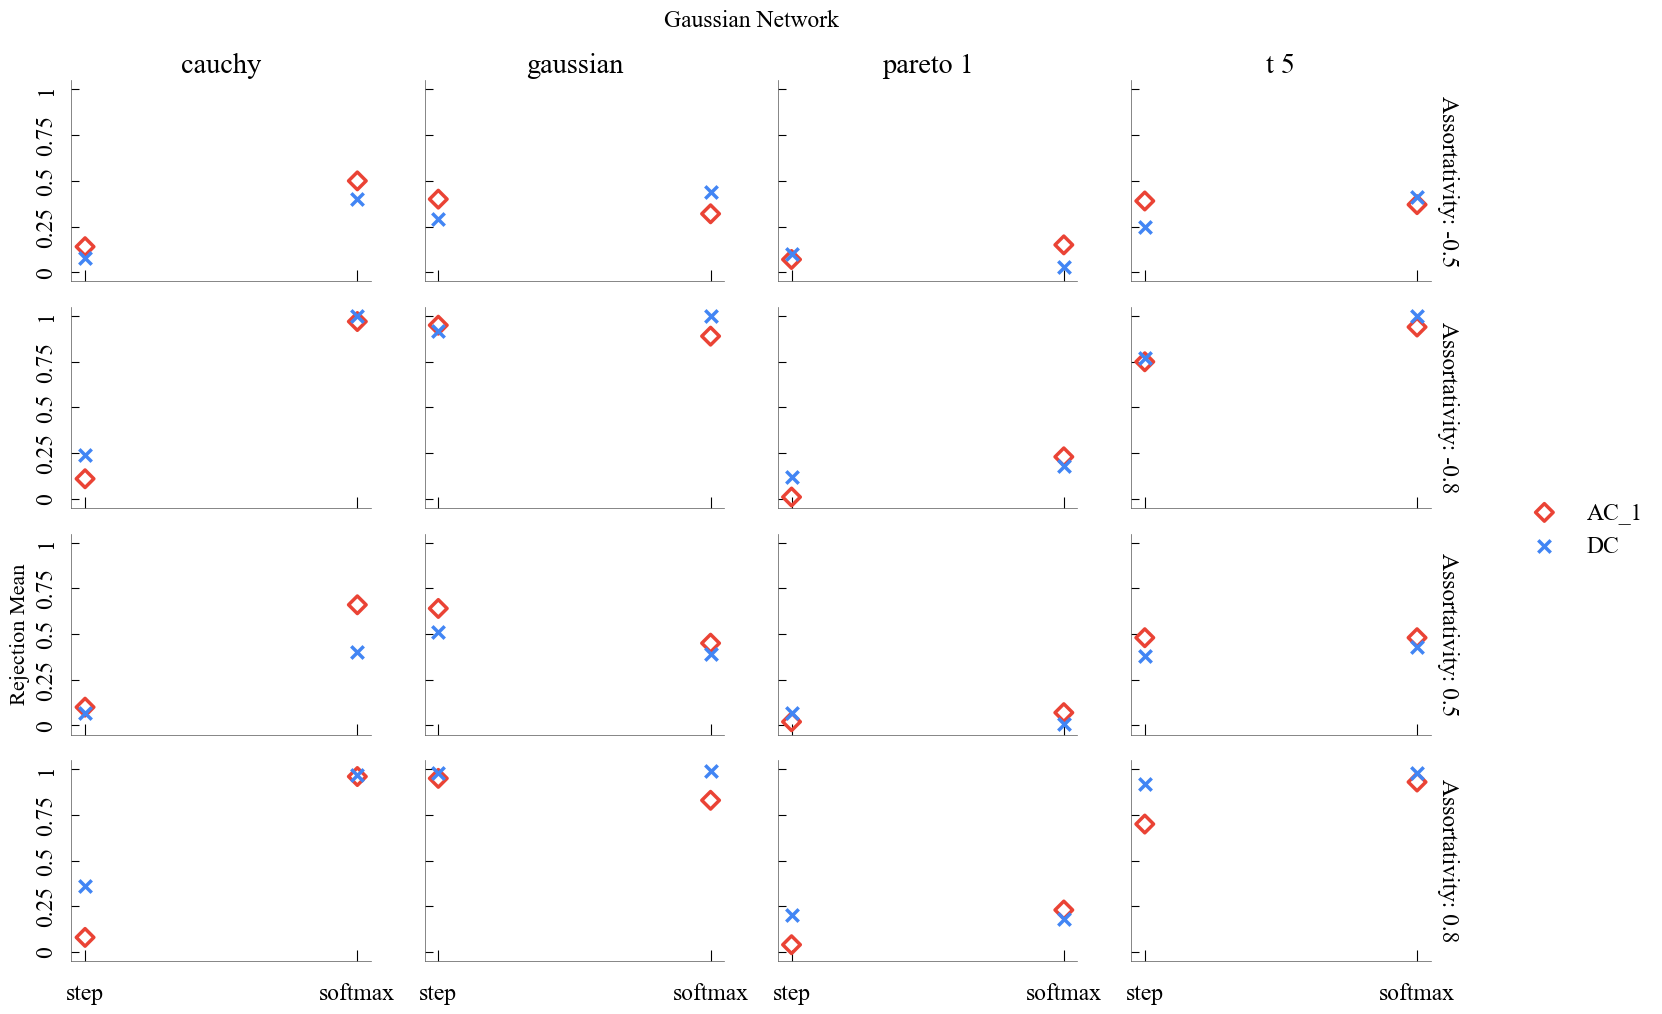

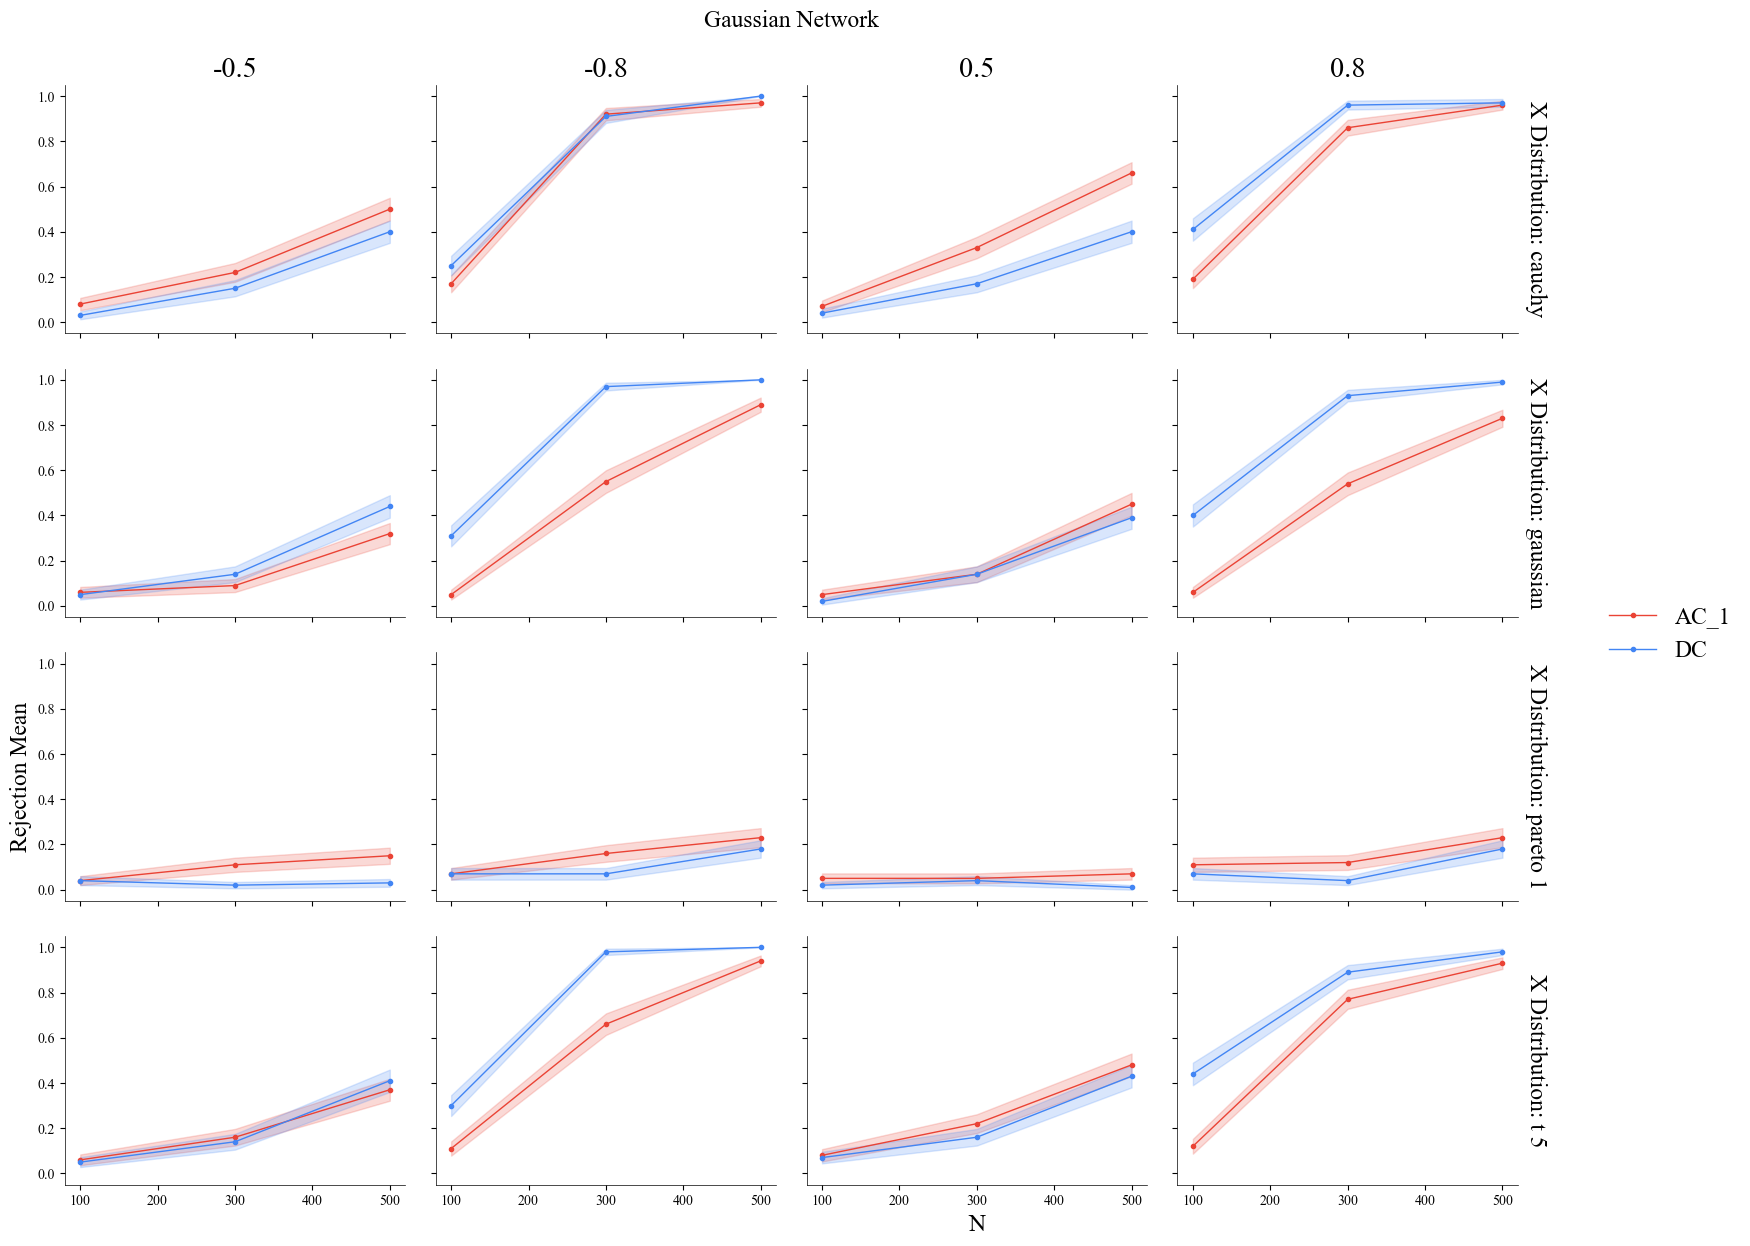

In [ ]:
all_sbm = ['step', 'softmax']

temp = agg_alt_gaussian.copy()
temp = temp[temp['sbm_covariate_sampling'].isin(all_sbm)]
temp = temp[temp['method'].isin(colors.keys())]

plot_grid(
    grouped_stats=temp[temp["n"] == 500],
    x_axis="sbm_covariate_sampling",
    y_axis="Rejection_mean",
    factors=["method", "x_distribution", 'assortativity'],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=2.5,
    aspect=1.5,
    add_legend=True,
    x_order=all_sbm,
    show_x_axis_title=False,
    show_col_names=False,
    x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=17,  # ← same for y (optional)
    x_tick_rotation=0,
    title="Gaussian Network",
)

# plot_grid(
#     grouped_stats=temp[temp['sbm_covariate_sampling'].isin(all_sbm[:1])],
#     plotting_function=plot_with_bands,
#     x_axis="n",
#     y_axis="Rejection_mean",
#     factors=["method", "assortativity", "x_distribution"],
#     height=3,
#     se_bands="Rejection_sem",
#     share_x=True,
#     share_y=True,
#     title="Gaussian Network",
#     colors=colors,
#     show_row_titles=True,
#     show_col_names=False,
# )

plot_grid(
    grouped_stats=temp[temp['sbm_covariate_sampling'].isin(all_sbm[1:])],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "assortativity", "x_distribution"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Gaussian Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
)